<a href="https://colab.research.google.com/github/Anshuman-kourav/Almabetter-Capstone-project/blob/main/polynomial_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression,SGDRegressor

from sklearn.preprocessing import PolynomialFeatures,StandardScaler

from sklearn.metrics import r2_score

from sklearn.pipeline import Pipeline

# Generate random data

In [ ]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

# y = 0.8x^2 + 0.9x + 2     random data equation

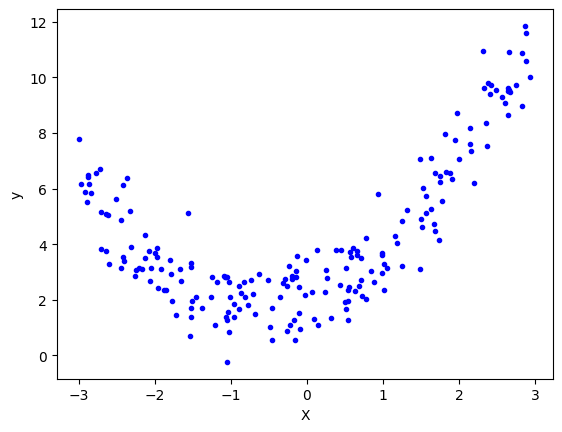

In [ ]:
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [ ]:
# Train test split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
# Applying linear regression
lr = LinearRegression()

In [ ]:
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.42136210179120737

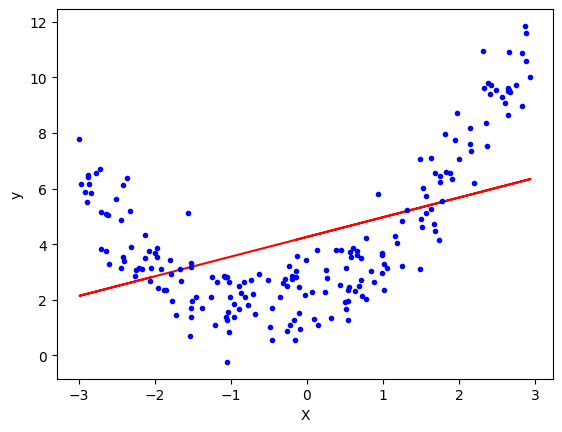

In [ ]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

# polynimial

polynomial **input column** ke uper apply karte hai , **output column (y)** ke uper nhi

but **transform** "test data" ke uper bhi karte hai

In [ ]:
# Applying Polynomial Linear Regression
# degree 2
poly = PolynomialFeatures(degree=2,include_bias=True)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [ ]:
print(X_test_trans[0])

[ 1.        -2.3703304  5.6184662]


In [ ]:
print(X_train[0])                     #--> original data
print(X_train_trans[0])               #--> transformed data

[-0.15548351]
[ 1.         -0.15548351  0.02417512]


In [ ]:
# include_bias parameter----by default (True) hota hai , if we set "False" so one particular input se two hi column milege (x^1,x^2)
# ye x^0 wala column hata dega means intercept wala term (its dependent upon data , hamare data me "intercept" hai(data equation me +2) isliye we take 'True')
# in real life data me hme equation nhi pata hoti toh ham , dono cheez try karte hai (False True)
poly = PolynomialFeatures(degree=2,include_bias=False)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [ ]:
print(X_train[0])                     #--> original data
print(X_train_trans[0])

[-0.15548351]
[-0.15548351  0.02417512]


In [ ]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [ ]:
y_pred = lr.predict(X_test_trans)

In [ ]:
r2_score(y_test,y_pred)

0.8939195237881292

In [ ]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.88664018 0.7551322 ]]
[2.16646423]


In [ ]:
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)

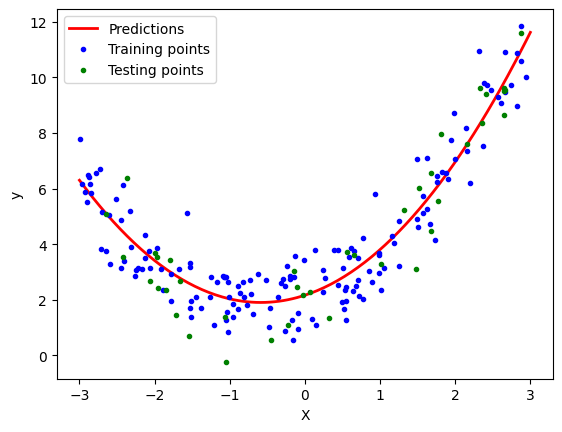

In [ ]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Function to check if we increas degree or reduce degree

In [ ]:
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()

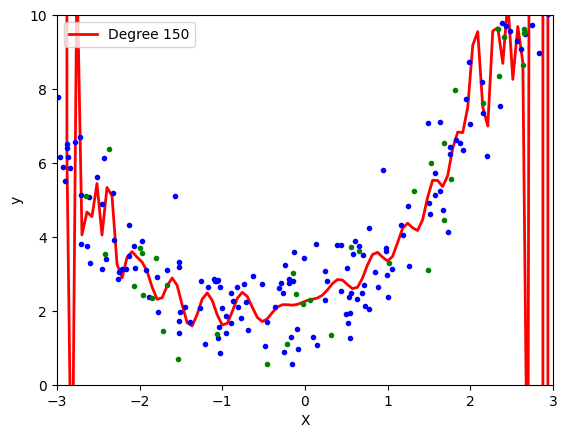

In [ ]:
polynomial_regression(150)

In [ ]:
poly.powers_

array([[0],
       [1],
       [2]], dtype=int64)

# Applying Gradient Descent

/usr/local/lib/python3.10/dist-packages/sklearn/utils/validation.py:1183: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


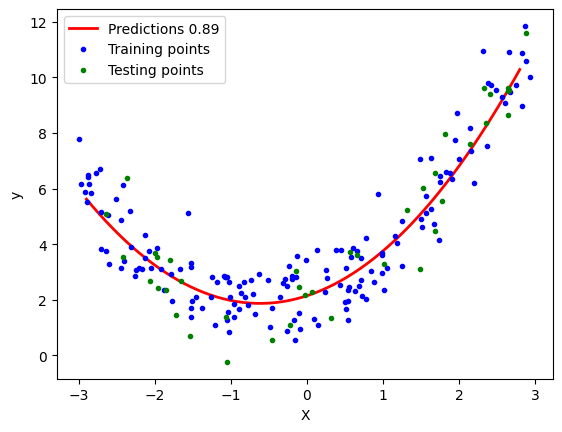

In [ ]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

# Multiple polinomial linear Regression

In [ ]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [ ]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [ ]:
lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)



In [ ]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

# Apply Polynomial in Multiple Linear regression

In [ ]:
X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [ ]:
poly = PolynomialFeatures(degree=2)
X_multi_trans = poly.fit_transform(X_multi)

In [ ]:
X_test_multi = poly.transform(final)

 2 column ke 6 column bne degree=2 ke liye

 [0,0]=degree 0

[1,0] = degree 1  ase hi sabhi me degree two hai

In [ ]:
print("input",poly.n_features_in_)
print("Ouput",poly.n_output_features_)
print("Powers\n",poly.powers_)

input 2
Ouput 6
Powers
 [[0 0]
 [1 0]
 [0 1]
 [2 0]
 [1 1]
 [0 2]]


In [ ]:
X_multi_trans.shape

(100, 6)

In [ ]:
lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [ ]:
z_final = lr.predict(X_test_multi)
# z_final = lr.predict(X_multi_trans).reshape(10,10)

In [ ]:
r2_score(z, z_final)

-1.048054022796347

In [ ]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()

# chatGpt

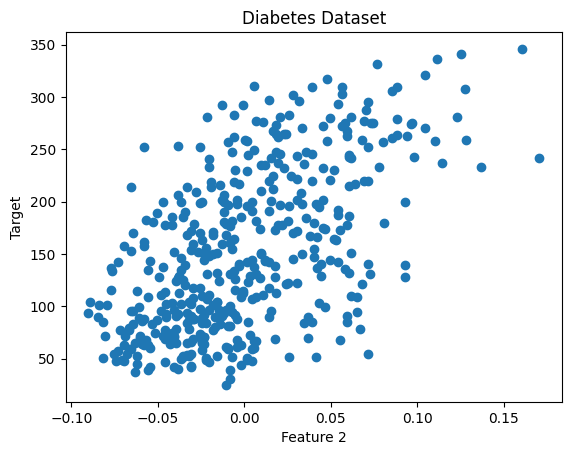

R² score for training set: 0.6134020651406564
R² score for testing set: 0.41343822343147074


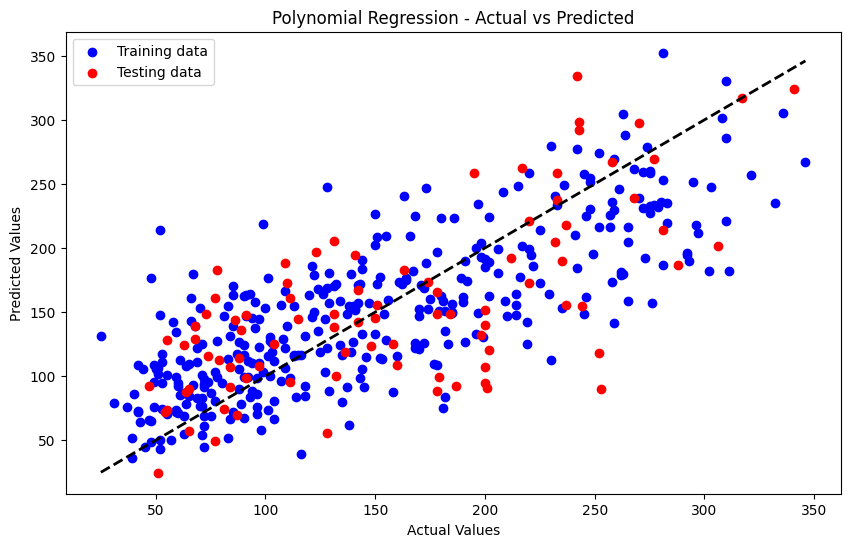

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# Load the diabetes dataset
X, y = load_diabetes(return_X_y=True)

plt.scatter(X[:, 2], y)
plt.xlabel('Feature 2')
plt.ylabel('Target')
plt.title('Diabetes Dataset')
plt.show()
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# Transform the features to polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train the polynomial regression model
model = LinearRegression()
model.fit(X_train_poly, y_train)

# Predict on the training and testing sets
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

# Calculate the R² score for training and testing sets
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R² score for training set: {r2_train}")
print(f"R² score for testing set: {r2_test}")

# Plotting the learning curve (optional)
plt.figure(figsize=(10, 6))
plt.scatter(y_train, y_train_pred, color='blue', label='Training data')
plt.scatter(y_test, y_test_pred, color='red', label='Testing data')
plt.plot([min(y), max(y)], [min(y), max(y)], color='black', lw=2, linestyle='--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Polynomial Regression - Actual vs Predicted')
plt.legend()
plt.show()


campux x

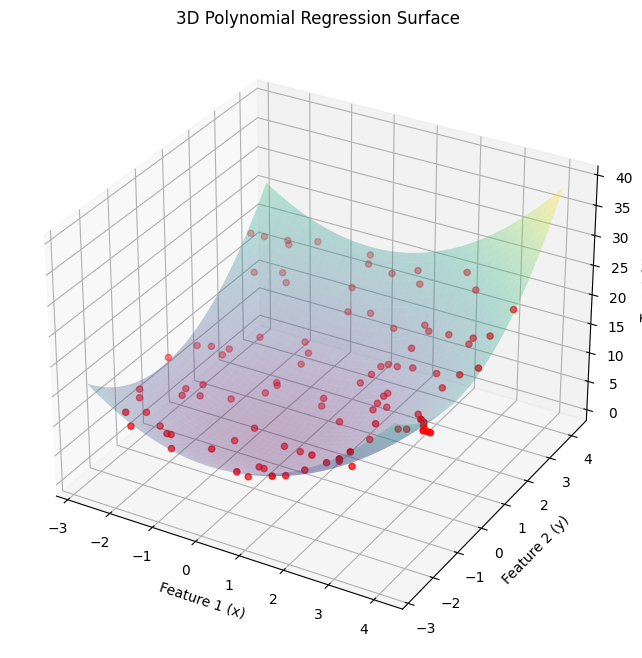

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# Generate the data
np.random.seed(0)
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8
z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y + 2 + np.random.randn(100, 1)

# Prepare the features for polynomial regression
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(np.hstack((x, y)))

# Train the polynomial regression model
model = LinearRegression()
model.fit(X_poly, z)

# Create a meshgrid for plotting the polynomial regression surface
x_input = np.linspace(x.min(), x.max(), 50)
y_input = np.linspace(y.min(), y.max(), 50)
xGrid, yGrid = np.meshgrid(x_input, y_input)

# Transform the grid to polynomial features
grid = np.c_[xGrid.ravel(), yGrid.ravel()]
grid_poly = poly.transform(grid)
zGrid = model.predict(grid_poly).reshape(xGrid.shape)

# Plotting the polynomial regression surface
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
ax.plot_surface(xGrid, yGrid, zGrid, alpha=0.3, cmap='viridis')

# Scatter plot of the original data points
ax.scatter(x, y, z, color='red')

ax.set_xlabel('Feature 1 (x)')
ax.set_ylabel('Feature 2 (y)')
ax.set_zlabel('Target (z)')
ax.set_title('3D Polynomial Regression Surface')

plt.show()


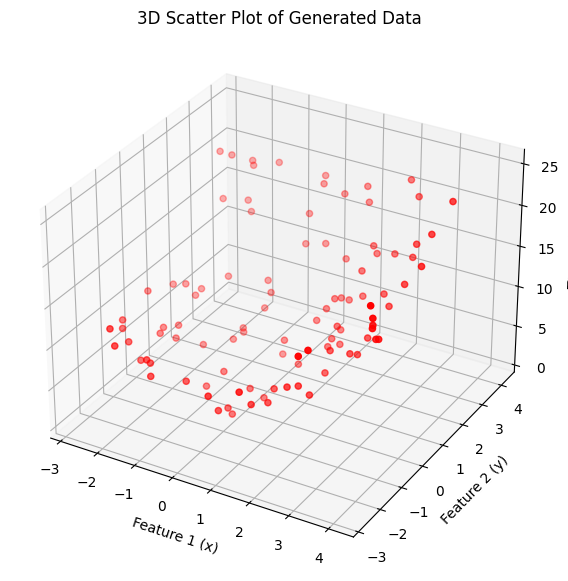

In [ ]:
# Create a scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, c='red', marker='o')

# Set labels and title
ax.set_xlabel('Feature 1 (x)')
ax.set_ylabel('Feature 2 (y)')
ax.set_zlabel('Target (z)')
ax.set_title('3D Scatter Plot of Generated Data')

plt.show()